<a href="https://colab.research.google.com/github/anshuman4515/Capstone-project/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import numpy as np
import pandas as pd
import re

In [84]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [85]:
df=pd.read_csv('/content/gurgaon_properties_cleaned_v1.csv')

In [86]:
df.duplicated().sum()

np.int64(121)

In [87]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,not available,1.0,NaN,Jun 2024,"['Sector 55-56 metro', 'Global city centre', 'Sohna road dhunela', 'Gd goenka university', 'Maharana pratap school', 'Vardaan hospital and trauma centre', 'Indira Gandhi International Airport', 'Garhi harsaru railway station Gurgaon']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Park', 'Visitor Parking']"


In [88]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
3229,1.30,1910.0,Carpet area: 1910 (177.44 sq.m.)
484,1.23,1480.0,Super Built up area 1480(137.5 sq.m.)
2830,1.10,1220.0,Super Built up area 1245(115.66 sq.m.)Carpet area: 1225 sq.ft. (113.81 sq.m.)
609,0.85,661.0,Carpet area: 661 (61.41 sq.m.)
2078,8.45,359.0,Plot area 359(33.35 sq.m.)


In [89]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None


In [90]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None


In [91]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [92]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [93]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3568,2.65,flat,1582.0,Carpet area: 124,NaN,NaN,124.0
3213,0.45,flat,531.0,Carpet area: 531 (49.33 sq.m.),NaN,NaN,531.0
422,1.70,flat,2200.0,Built Up area: 2200 (204.39 sq.m.)Carpet area: 1610 sq.ft. (149.57 sq.m.),NaN,2200.0,1610.0
2133,1.00,flat,1503.0,Super Built up area 1503(139.63 sq.m.)Built Up area: 1300 sq.ft. (120.77 sq.m.)Carpet area: 1200 sq.ft. (111.48 sq.m.),1503.0,1300.0,1200.0
2311,0.75,flat,1095.0,Super Built up area 1095(101.73 sq.m.),1095.0,NaN,NaN


In [94]:
df.duplicated().sum()

np.int64(121)

In [95]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [96]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,1.95,house,1935.0,Plot area 215(179.77 sq.m.),NaN,NaN,NaN
15,1.40,house,585.0,Plot area 65(54.35 sq.m.)Built Up area: 62 sq.yards (51.84 sq.m.)Carpet area: 60 sq.yards (50.17 sq.m.),NaN,62.0,60.0
41,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
43,4.40,house,2880.0,Plot area 320(267.56 sq.m.),NaN,NaN,NaN
53,4.31,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [97]:
df.isnull().sum()


,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,1392


In [98]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [99]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,1.95,house,1935.0,Plot area 215(179.77 sq.m.),NaN,NaN,NaN
41,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
43,4.40,house,2880.0,Plot area 320(267.56 sq.m.),NaN,NaN,NaN
53,4.31,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
56,10.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [100]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [101]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None


In [102]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [103]:
# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [104]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,1.95,house,1935.0,Plot area 215(179.77 sq.m.),NaN,215.00,NaN
41,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.00,NaN
43,4.40,house,2880.0,Plot area 320(267.56 sq.m.),NaN,320.00,NaN
53,4.31,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
56,10.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
60,10.30,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
74,13.50,house,4518.0,Plot area 502(419.74 sq.m.),NaN,502.00,NaN
89,6.20,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.00,NaN
97,2.99,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.00,NaN
106,3.75,house,1467.0,Plot area 163(136.29 sq.m.),NaN,163.00,NaN


In [105]:
def convert_to_sqft(row):
  if np.isnan(row['area']) or np.isnan(row['built_up_area']):
    return row['built_up_area']

  else:
    if round(row['area']/row['built_up_area'])==9.0:
      return row['built_up_area']*9
    elif round(row['area']/row['built_up_area'])==11.0:
      return row['built_up_area']*10.7
    else:
      return row['built_up_area']



In [106]:
all_nan_df['built_up_area']=all_nan_df.apply(convert_to_sqft, axis=1)

In [107]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,1.95,house,1935.0,Plot area 215(179.77 sq.m.),NaN,1935.00,NaN
41,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,2430.00,NaN
43,4.40,house,2880.0,Plot area 320(267.56 sq.m.),NaN,2880.00,NaN
53,4.31,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
56,10.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
60,10.30,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
74,13.50,house,4518.0,Plot area 502(419.74 sq.m.),NaN,4518.00,NaN
89,6.20,house,2430.0,Plot area 270(225.75 sq.m.),NaN,2430.00,NaN
97,2.99,house,1449.0,Plot area 161(134.62 sq.m.),NaN,1449.00,NaN
106,3.75,house,1467.0,Plot area 163(136.29 sq.m.),NaN,1467.00,NaN


In [108]:
df.update(all_nan_df)

In [109]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,18
price_per_sqft,18
area,18
areaWithType,0
bedRoom,0
bathroom,0
balcony,1392


In [110]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,not available,1.0,NaN,Jun 2024,"['Sector 55-56 metro', 'Global city centre', 'Sohna road dhunela', 'Gd goenka university', 'Maharana pratap school', 'Vardaan hospital and trauma centre', 'Indira Gandhi International Airport', 'Garhi harsaru railway station Gurgaon']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Park', 'Visitor Parking']",NaN,1120.0,NaN
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9062.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,servant room,16.0,South,1 to 5 Year Old,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road', 'Dwarka Expy', 'Prime Scholars International School', 'DPG Degree College', 'The Signature Advanced Super Speciality', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station', 'Altrade Business Centre', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park Gurgaon', 'Hamoni Golf Camp', 'Nehru Stadium']","['1 Stove', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1931.0,NaN,NaN
2,flat,Raheja Vedaanta3.6 ★,sector 108,0.70,4666.0,1500.0,Built Up area: 1468 (136.38 sq.m.)Carpet area: 1150 sq.ft. (106.84 sq.m.),2.0,2.0,1.0,not available,10.0,West,5 to 10 Year Old,NaN,NaN,NaN,NaN,1468.0,1150.0
3,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet area: 2900 sq.ft. (269.42 sq.m.),4.0,4.0,3.0,servant room,12.0,West,1 to 5 Year Old,"['Delhi Public School', 'Raheja Market', 'Sapphire Mall', 'INXT High Street', 'Cambridge Pre-School', 'Euro Int. School', 'Genesis Hospital', 'HDFC Bank', 'Society Park', 'Dishoom Cinemas']",NaN,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Visitor Parking']",3434.0,NaN,2900.0
4,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up area: 3000 sq.ft. (278.71 sq.m.)Carpet area: 2800 sq.ft. (260.13 sq.m.),4.0,5.0,3.0,servant room,10.0,South-West,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dreamz Mall', 'HUDA Market, Sector 14', 'Dwarka Expressway', 'Delhi Gurgaon Expressway', 'Sanskar Bharti Public School', 'The NorthCap University', 'Manipal Hospital, Gurugram', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'The Oberoi, Gurgaon', 'Fun N Food Village', 'InfinityS Badminton Academy', 'F9 Go Karting Gurgaon', 'SCC Rooftop Drive-In']","['6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden

2.additional room


In [111]:
df['additionalRoom'].value_counts()


,count
additionalRoom,
not available,1587
servant room,705
study room,250
others,225
pooja room,165
"study room,servant room",99
store room,99
"pooja room,servant room",82
"pooja room,study room,servant room,store room",72


In [112]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [113]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
1141,not available,0,0,0,0,0
2185,others,0,0,0,0,1
897,servant room,0,1,0,0,0
2639,store room,0,0,1,0,0
2645,not available,0,0,0,0,0


In [114]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,not available,1.0,NaN,Jun 2024,"['Sector 55-56 metro', 'Global city centre', 'Sohna road dhunela', 'Gd goenka university', 'Maharana pratap school', 'Vardaan hospital and trauma centre', 'Indira Gandhi International Airport', 'Garhi harsaru railway station Gurgaon']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Park', 'Visitor Parking']",NaN,1120.0,NaN,0,0,0,0,0
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9062.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,servant room,16.0,South,1 to 5 Year Old,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road', 'Dwarka Expy', 'Prime Scholars International School', 'DPG Degree College', 'The Signature Advanced Super Speciality', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station', 'Altrade Business Centre', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park Gurgaon', 'Hamoni Golf Camp', 'Nehru Stadium']","['1 Stove', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1931.0,NaN,NaN,0,1,0,0,0
2,flat,Raheja Vedaanta3.6 ★,sector 108,0.70,4666.0,1500.0,Built Up area: 1468 (136.38 sq.m.)Carpet area: 1150 sq.ft. (106.84 sq.m.),2.0,2.0,1.0,not available,10.0,West,5 to 10 Year Old,NaN,NaN,NaN,NaN,1468.0,1150.0,0,0,0,0,0
3,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet area: 2900 sq.ft. (269.42 sq.m.),4.0,4.0,3.0,servant room,12.0,West,1 to 5 Year Old,"['Delhi Public School', 'Raheja Market', 'Sapphire Mall', 'INXT High Street', 'Cambridge Pre-School', 'Euro Int. School', 'Genesis Hospital', 'HDFC Bank', 'Society Park', 'Dishoom Cinemas']",NaN,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Visitor Parking']",3434.0,NaN,2900.0,0,1,0,0,0
4,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up area: 3000 sq.ft. (278.71 sq.m.)Carpet area: 2800 sq.ft. (260.13 sq.m.),4.0,5.0,3.0,servant room,10.0,South-West,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dreamz Mall', 'HUDA Market, Sector 14', 'Dwarka Expressway', 'Delhi Gurgaon Expressway', 'Sanskar Bharti Public School', 'The NorthCap University', 'Manipal Hospital, Gurugram', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'The Oberoi, Gurgaon', 'Fun N Food Village', 'InfinityS Badminton Academy', 'F9 Go Karting Gurgaon', 'SCC Rooftop Drive-In']","['6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifie

3. age possession


In [115]:
df['agePossession'].value_counts()

,count
agePossession,
1 to 5 Year Old,1676
5 to 10 Year Old,575
0 to 1 Year Old,530
undefined,332
10+ Year Old,310
Under Construction,90
Within 6 months,70
Within 3 months,26
Dec 2023,22


In [116]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"


In [117]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)


In [118]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1676
New Property,626
Moderately Old,575
Undefined,333
Old Property,310
Under Construction,283


4.firnish detail


In [119]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3068,NaN,"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Bank Attached Property', 'Visitor Parking', 'Natural Light', 'Airy Rooms', 'Shopping Centre']"
1984,"['5 Wardrobe', '5 Fan', '11 Light', '6 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking', 'Fitness Centre / GYM']"
3490,"['1 Geyser', '1 Chimney', '2 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water Storage', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']"
521,NaN,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Separate entry for servant room', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
3565,"['1 Exhaust Fan', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No AC', 'No Bed', 'No Dining Table', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [120]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1571/2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [121]:
furnishings_df.shape

(3803, 19)

In [122]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/tmp/ipykernel_1571/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [123]:
furnishings_df.sample(5)

,Dining Table,Fridge,Microwave,Chimney,Geyser,Light,Sofa,Washing Machine,AC,Modular Kitchen,Exhaust Fan,Wardrobe,Curtains,TV,Stove,Fan,Bed,Water Purifier
3366,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3075,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0
1271,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0
1847,0,0,0,0,3,15,0,0,0,0,0,3,0,0,0,7,0,0
1127,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [124]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [125]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [126]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

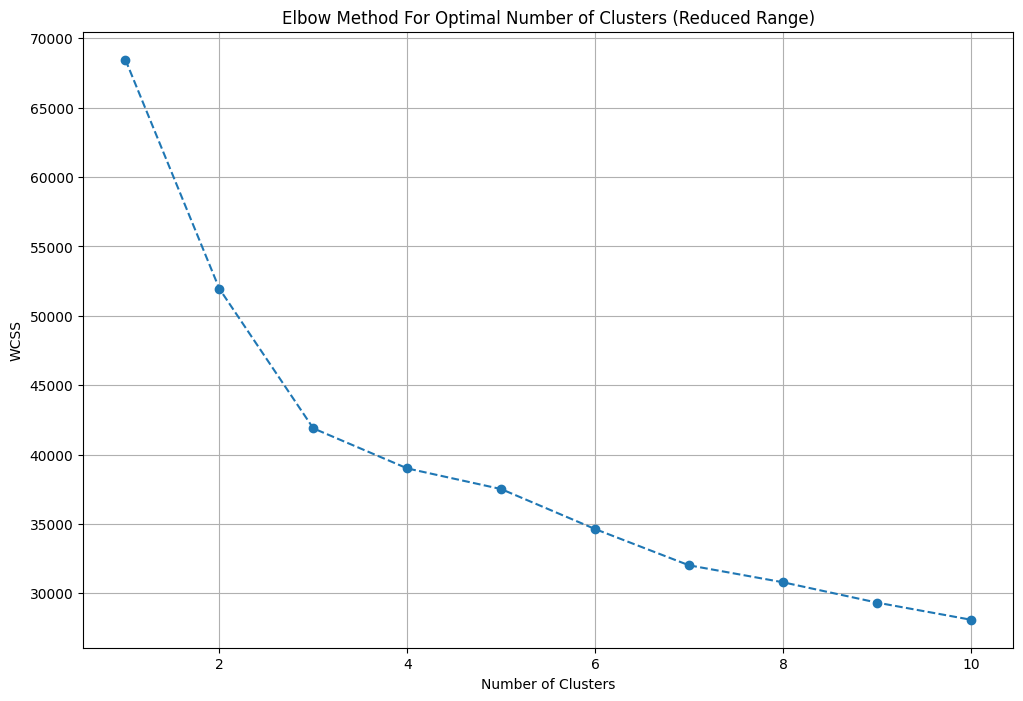

In [127]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [128]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [129]:
df = df.iloc[:,:-18]

In [130]:
df['furnishing_type'] = cluster_assignments

In [131]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
1777,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
837,"['5 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
2602,NaN,0
437,[],0
3229,NaN,0


5.features

In [132]:
df[['society','features']].sample(5)

,society,features
1066,Kiran Residency,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
912,Tulip Violet4.2 ★,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
605,independent,"['Feng Shui / Vaastu Compliant', 'Visitor Parking']"
45,Vatika Gurgaon 213.7 ★,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
785,Oriental Valley CHS,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park']"


In [133]:
df['features'].isnull().sum()

np.int64(635)

In [134]:
import pandas as pd
app_df = pd.read_csv('/content/appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [135]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [136]:
temp_df = df[df['features'].isnull()]

In [137]:
temp_df.shape

(635, 26)

In [138]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [139]:
df.loc[temp_df.index,'features'] = x.values

In [142]:
df['features'].isnull().sum()

np.int64(618)

In [143]:

from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [144]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [145]:
features_binary_df.sample(5)

,24/7 Power Backup,24x7 Security,ATM,Aerobics Centre,Airy Rooms,Amphitheatre,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Creche/Day care,Cricket Pitch,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Landscape Garden,Laundry,Lawn Tennis Court,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Natural Light,No open drainage around,Park,Pergola,Piped Gas,Piped-gas,Power Back-up,Private Garden / Terrace,Property Staff,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Terrace Garden,Video Door Security,Visitor Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
222,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,1,0,0
3275,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0
1077,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,1,0,0
1101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
3280,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0


In [146]:
features_binary_df.shape

(3803, 96)

In [147]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

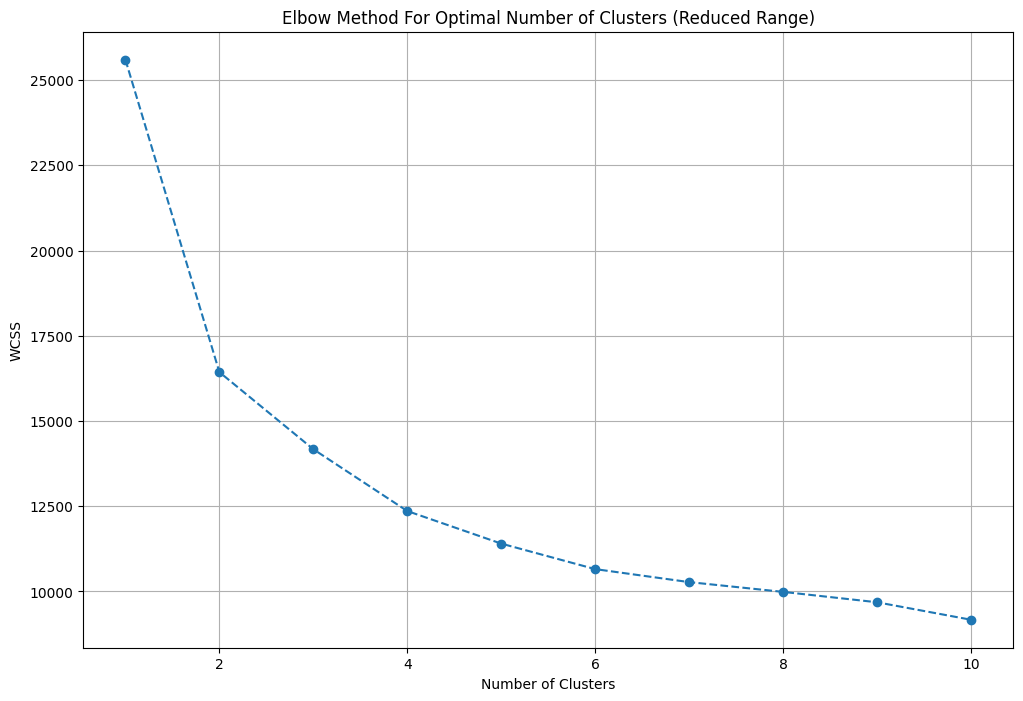

In [148]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [151]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}


KeyError: "['24/7 Water Supply', 'Badminton Court', 'Basketball Court', 'Billiards', 'Car Parking', 'Concierge Service', 'Conference room', 'Doctor on Call', 'Food Court', 'Foosball', 'Football', 'High Speed Elevators', 'Infinity Pool', 'Jogging Track', 'Library', 'Multipurpose Court', 'Multipurpose Hall', 'Natural Pond', 'Party Lawn', 'Pool Table', 'Power Back up Lift', 'RO System', 'Solar Water Heating', 'Temple', 'Theatre', 'Toddler Pool', 'Valet Parking', 'Water Softener Plant'] not in index"

In [152]:
valid_cols = [col for col in weights.keys() if col in features_binary_df.columns]

luxury_score = (
    features_binary_df[valid_cols]
    .multiply([weights[col] for col in valid_cols])
    .sum(axis=1)
)

In [153]:
df['luxury_score'] = luxury_score

In [154]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,signature global park,sohna road,0.85,7589.0,1120.0,Built Up area: 1120 (104.05 sq.m.),3.0,2.0,2.0,not available,1.0,NaN,Under Construction,"['Sector 55-56 metro', 'Global city centre', 'Sohna road dhunela', 'Gd goenka university', 'Maharana pratap school', 'Vardaan hospital and trauma centre', 'Indira Gandhi International Airport', 'Garhi harsaru railway station Gurgaon']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Park', 'Visitor Parking']",NaN,1120.0,NaN,0,0,0,0,0,0,"[Park, Visitor Parking]",15
1,flat,Conscient Heritage Max4.3 ★,sector 102,1.75,9062.0,1931.0,Super Built up area 1931(179.4 sq.m.),3.0,4.0,NaN,servant room,16.0,South,Relatively New,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road', 'Dwarka Expy', 'Prime Scholars International School', 'DPG Degree College', 'The Signature Advanced Super Speciality', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station', 'Altrade Business Centre', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park Gurgaon', 'Hamoni Golf Camp', 'Nehru Stadium']","['1 Stove', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']",1931.0,NaN,NaN,0,1,0,0,0,1,"[Security / Fire Alarm, Feng Shui / Vaastu Compliant, Intercom Facility, Lift(s), Centrally Air Conditioned, High Ceiling Height, Maintenance Staff, Water Storage, Separate entry for servant room, No open drainage around, Bank Attached Property, Visitor Parking, Swimming Pool, Park, Natural Light, Internet/wi-fi connectivity, Airy Rooms, Low Density Society, Shopping Centre, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center, Water softening plant]",134
2,flat,Raheja Vedaanta3.6 ★,sector 108,0.70,4666.0,1500.0,Built Up area: 1468 (136.38 sq.m.)Carpet area: 1150 sq.ft. (106.84 sq.m.),2.0,2.0,1.0,not available,10.0,West,Moderately Old,NaN,NaN,NaN,NaN,1468.0,1150.0,0,0,0,0,0,0,[],0
3,flat,Alpha Corp GurgaonOne 844.0 ★,sector 84,2.24,6523.0,3434.0,Super Built up area 3434(319.03 sq.m.)Carpet area: 2900 sq.ft. (269.42 sq.m.),4.0,4.0,3.0,servant room,12.0,West,Relatively New,"['Delhi Public School', 'Raheja Market', 'Sapphire Mall', 'INXT High Street', 'Cambridge Pre-School', 'Euro Int. School', 'Genesis Hospital', 'HDFC Bank', 'Society Park', 'Dishoom Cinemas']",NaN,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Visitor Parking']",3434.0,NaN,2900.0,0,1,0,0,0,0,"[Intercom Facility, Lift(s), Maintenance Staff, Visitor Parking]",20
4,flat,Indiabulls Enigma,sector 110,3.40,10000.0,3400.0,Super Built up area 3400(315.87 sq.m.)Built Up area: 3000 sq.ft. (278.71 sq.m.)Carpet area: 2800 sq.ft. (260.13 sq.m.),4.0,5.0,3.0,servant room,10.0,South-West,Relatively New,"['Dwarka Sector 21 Metro Station',

In [155]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [156]:
df.shape

(3803, 23)

In [157]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)